In [23]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
os.getcwd()

'/scale/user/mtannaou/alternance'

In [24]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd;import xarray as xr;import numpy as np;import os
import src.IR_to_SAR.data_preparation.data_preprocessing as dataprep
from src.IR_to_SAR.data_preparation.distribution_data_visualisation import plot_sar,plot_ir,plot_aam
from src.IR_to_SAR.ML_IR_SAR.model import create_model

from importlib import reload
reload(dataprep)
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt;import xarray as xr;import pickle as pkl;import os;import torch
from src.IR_to_SAR.data_preparation.data_preprocessing import create_moment_sar,annular_normalization,annular_denormalization,moment_to_sar,z_score

In [25]:
def denorm(t, mean, std):
            
            return t * (std + 1e-10) + mean

import torch
import torch.nn as nn
from diffusers import UNet2DModel, UNet2DConditionModel


def create_model(
    image_size=None,   # patch final utile
    in_channels=1,           # IR 
    out_channels=1,          # SAR output (wind speed map)
    block_out_channels=None,
    dropout= 0.0,
    down_block_types=None,
    up_block_types=None,
    conditional_model = False,
    cross_attention_dim=0,
    batch_size=None,
    cond_dim=16
):
    """
    Creates a UNet2DModel with the specified configuration.
    """
    if not conditional_model:
        model = UNet2DModel(
            sample_size=image_size,
            in_channels=in_channels,
            out_channels=out_channels,
            block_out_channels=block_out_channels,
            down_block_types=down_block_types,
            up_block_types=up_block_types,
            dropout=dropout,
            norm_num_groups=16
        )

    return model

def annular_denormalization(images_norm, stats, bin_size=1):
            # images_norm: (B,H,W)
            N, H, W = images_norm.shape
            cx, cy = W// 2, H // 2
            y, x_ = np.indices((H, W))
            radius = np.sqrt((y - cy) ** 2 + (x_ - cx) ** 2)
            radial_bins = (radius // bin_size).astype(np.int32)
            mean = stats["mean"]
            std = stats["std"]
            images = images_norm.copy()
            for b in range(len(mean)):
                images[:, radial_bins == b] = images[:, radial_bins == b] * std[b] + mean[b]
            return images

def moment_to_sar(moment):
    # moment: (B,H,W)
    assert moment.ndim == 3, "moment must be (B,H,W)"
    B, H, W = moment.shape
    y, x = np.indices((H, W))
    cy, cx = H // 2, W // 2
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_safe = np.maximum(r, 1.0)
    return moment / r_safe[None, :, :]

In [26]:
i_folder=23
anggrek_csv = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv")
tcva_csv = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/TCVA_matched_with_SARGEO_v3_split_by_year.csv")
dir = f"/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/UNETSARGEO/train_ir_sar_{i_folder}"
with open(os.path.join(dir,"stats_normalisation/Anggrek_data_normalised/data.pkl"),"rb") as f:
    data_anggrek= pkl.load(f)
with open(os.path.join(dir,"stats_normalisation/OUTPUT/stats.pkl"),"rb") as f:
    stats_anggrek = pkl.load(f)
ir_anggrek_norm = data_anggrek["IR_anggrek"].squeeze()
mean_x, std_x = stats_anggrek["mean_x"][0], stats_anggrek["std_x"][0]
mean_sar, std_sar = stats_anggrek["mean_sar"], stats_anggrek["std_sar"]
ir_anggrek_norm.squeeze().shape

(153, 128, 128)

In [27]:
model = create_model(
    image_size=128,
    in_channels=1,
    out_channels=1,
    block_out_channels=(16, 16, 32, 64), 
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
)
model = model.to("cuda")
ckpt_path = os.path.join(dir,"best_regression_model.pt")
ckpt = torch.load(ckpt_path, map_location="cuda")
state_dict = ckpt["model"]
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("✅ Loaded with strict=False")
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))
model.eval()

✅ Loaded with strict=False
Missing keys: 0
Unexpected keys: 0


UNet2DModel(
  (conv_in): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=16, out_features=64, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=64, out_features=64, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(16, 16, eps=1e-05, affine=True)
          (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=64, out_features=16, bias=True)
          (norm2): GroupNorm(16, 16, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(16, 16, k

In [28]:
ir_denorm  = denorm(ir_anggrek_norm,mean_x,std_x)
aam_predictions = []
for ir in ir_anggrek_norm:
    ir_tensor = (
        torch.from_numpy(ir)
        .float()
        .unsqueeze(0)   # batch
        .unsqueeze(0)   # channel
        .to("cuda")
    )

    with torch.no_grad():
        out = model(ir_tensor, timestep=0)
        aam_pred = out.sample if hasattr(out, "sample") else out

    aam_predictions.append(aam_pred.squeeze().cpu().numpy())

aam_denorm = annular_denormalization(np.array(aam_predictions), stats={"mean": mean_sar, "std": std_sar})
sar_pred = aam_denorm #moment_to_sar(aam_denorm)
sar_pred.shape

(153, 128, 128)

In [29]:
ind = -1

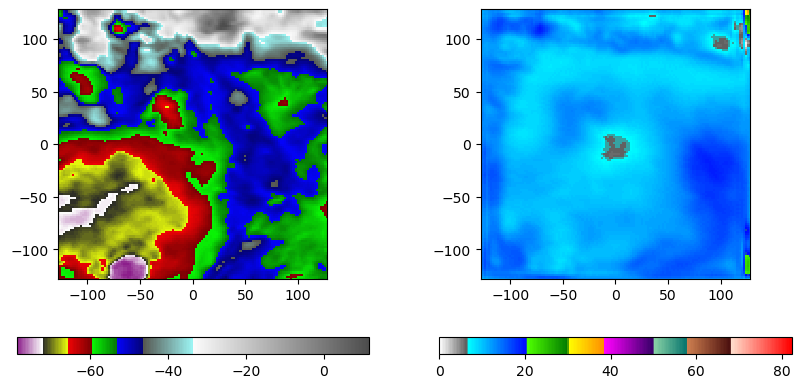

In [30]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
ind +=1
plot_sar(sar_pred[ind],fig=fig,ax=axes[1],x_lim=sar_pred.shape[1])
plot_ir(ir_denorm[ind],fig=fig,ax=axes[0],x_lim=ir_denorm.shape[1])

In [31]:
import torch.nn.functional as F
def resample_2km_to_3km_torch(xs):
    resamples = []

    for x in xs:
        
        x = torch.as_tensor(x, dtype=torch.float32, device="cuda")

        # HxW -> 1x1xHxW
        if x.dim() == 2:
            x = x.unsqueeze(0).unsqueeze(0)

        H, W = x.shape[-2:]
        new_H = int(H * 2 / 3)
        new_W = int(W * 2 / 3)

        # CPU interpolation
        x3 = F.interpolate(x, size=(new_H, new_W), mode="bilinear", align_corners=False)

        # back to numpy (HxW)
        resamples.append(x3.squeeze(0).squeeze(0).cpu().numpy())

    return np.stack(resamples, axis=0)

In [32]:
def compute_vmax1d_rmax1d(sar_2d,rayon=100):
        """
        Compute Vmax1D and Rmax1D from a 2D SAR field.
        - Vmax1D: maximum wind speed along radial profile
        - Rmax1D: radius at which Vmax1D occurs
        """
        H, W = sar_2d.shape
        sar_2d = sar_2d[W//2-rayon//2:W//2+rayon//2,H//2-rayon//2:H//2+rayon//2]
        H, W = sar_2d.shape
        cx, cy = W//2, H//2
        Y, X = np.indices((H, W))
        R = np.sqrt((X - cx)**2 + (Y - cy)**2)
        Rmax = int(R.max())
        radii = np.arange(0, Rmax)
        vmax_profile = []
        for R0 in radii:
            mask = (np.abs(R - R0) < 0.5)
            if np.sum(mask) == 0:
                vmax_profile.append(np.nan)
            else:
                vmax_profile.append(np.nanmax(sar_2d[mask]))
        vmax_profile = np.array(vmax_profile)
        # Remove NaNs
        valid = ~np.isnan(vmax_profile)
        vmax_profile = vmax_profile[valid]
        radii = radii[valid]
        vmax1d = np.nanmax(vmax_profile)
        rmax1d = radii[np.nanargmax(vmax_profile)]
        vmax1d_ms = vmax1d
        rmax1d_km = rmax1d * 2
        return vmax1d_ms, rmax1d_km

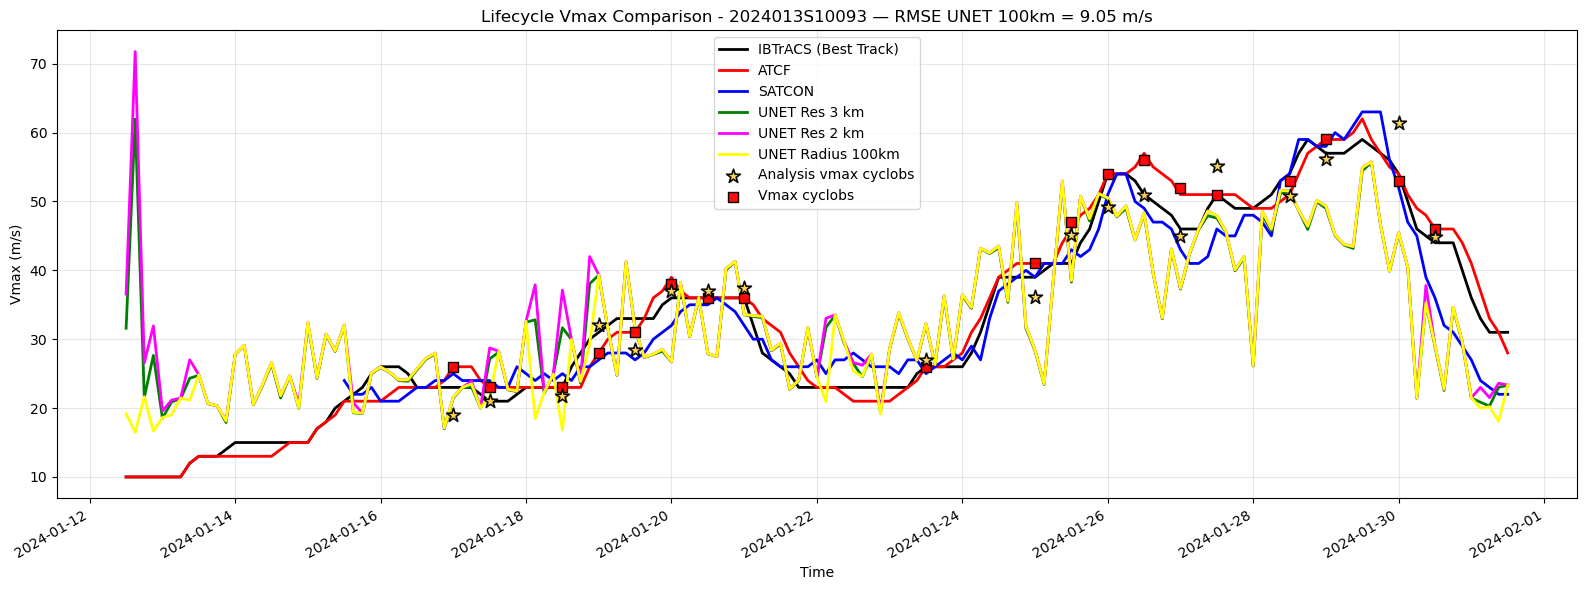

In [33]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
sar_time = anggrek_csv["date"].values
time_parsed = pd.to_datetime(sar_time, errors="coerce")
order = np.argsort(time_parsed.values.astype("datetime64[ns]"))

ir_den = ir_denorm[order]
pred_den = sar_pred[order]
time_parsed = time_parsed[order]
pred_denorm_3m = resample_2km_to_3km_torch(pred_den)
vmax = np.array(anggrek_csv["wind_speed (m/s)"].values)
vmax_cyclobs = np.array(anggrek_csv["vmax_cyclobs"].values)
analysis_vmax_cyclobs = np.array(anggrek_csv["analysis_vmax_cyclobs"].values)
ibtracs_vmax = np.array(anggrek_csv["ibtracs_vmax"].values)
satcon_vmax  = np.array(anggrek_csv["satcon_vmax"].values)
pred_vmax = np.nanmax(pred_denorm_3m.reshape(len(pred_den), -1), axis=1)
pred_vmax_2km = np.nanmax(pred_den.reshape(len(pred_den), -1), axis=1)
pred_vmax_100km = []
for sar_pred in pred_den:
    pred_vmax_100km.append(compute_vmax1d_rmax1d(sar_pred,100)[0])
pred_vmax_100km = np.array(pred_vmax_100km)


ok = np.isfinite(vmax) & np.isfinite(pred_vmax)
rmse = float(np.sqrt(np.mean((pred_vmax_100km[ok] - vmax[ok]) ** 2))) if np.any(ok) else np.nan

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(time_parsed, ibtracs_vmax, color="black", linewidth=2, label="IBTrACS (Best Track)")
ax.plot(time_parsed, vmax, color="red", linewidth=2, label="ATCF")
ax.plot(time_parsed, satcon_vmax, color="blue", linewidth=2, label="SATCON")


ax.plot(time_parsed, pred_vmax, color="green", linewidth=2, label="UNET Res 3 km")
ax.plot(time_parsed, pred_vmax_2km, color="magenta", linewidth=2, label="UNET Res 2 km")
ax.plot(time_parsed, pred_vmax_100km, color="yellow", linewidth=2, label="UNET Radius 100km")

analysis_arr = np.array(analysis_vmax_cyclobs, dtype=float)
cyclobs_arr  = np.array(vmax_cyclobs, dtype=float)

t = np.array(time_parsed)
analysis_arr = np.array(analysis_vmax_cyclobs, dtype=float)
cyclobs_arr  = np.array(vmax_cyclobs, dtype=float)

t = np.array(time_parsed)

mA = ~np.isnan(analysis_arr)
mC = ~np.isnan(cyclobs_arr)


# --- Markers (high-quality style)
ax.scatter(
    t[mA], analysis_arr[mA],
    marker="*", s=110,                  # size
    facecolor="#FFD54F",                # warm yellow
    edgecolor="black", linewidths=1.2,  # black outline
    alpha=0.95,
    zorder=10,
    label = "Analysis vmax cyclobs"
)

ax.scatter(
    t[mC], cyclobs_arr[mC],
    marker="s", s=55,
    facecolor="#FF0000",                # deep green
    edgecolor="black", linewidths=1.0,
    alpha=0.95,
    zorder=9,
    label ="Vmax cyclobs"
)

# --- Optional: custom legend handles (so legend looks perfect)
handles, labels = ax.get_legend_handles_labels()

analysis_handle = Line2D(
    [0], [0], marker="*", linestyle="None",
    markerfacecolor="#FFD54F", markeredgecolor="black",
    markeredgewidth=1.2, markersize=12,
    label="Analysis vmax cyclobs"
)

cyclobs_handle = Line2D(
    [0], [0], marker="s", linestyle="None",
    markerfacecolor="#2E7D32", markeredgecolor="black",
    markeredgewidth=1.0, markersize=8,
    label="Vmax cyclobs"
)

# Put them at the end (or insert wherever you want)
handles += [analysis_handle, cyclobs_handle]
ax.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.9)
ax.set_title(f"Lifecycle Vmax Comparison - 2024013S10093 — RMSE UNET 100km = {rmse:.2f} m/s")
ax.set_xlabel("Time")
ax.set_ylabel("Vmax (m/s)")

# clean date axis like your IBTrACS figure
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(dir,"anggrek_monitoring","vmax_all_comparison.png"), dpi=150)
plt.close(fig)

## Creation de la grille lon lat

In [34]:
import numpy as np
import pandas as pd
import xarray as xr

out_dir   = os.path.join("unetsargeo",f"v0{i_folder}","2024013S10093")
os.makedirs(out_dir, exist_ok=True)
lifecycle_path   = os.path.join("unetsargeo",f"v0{i_folder}","lifecycle_diagnostics")
os.makedirs(lifecycle_path, exist_ok=True)

time_col = "date"    
lat_col  = "lat"     
lon_col  = "lon"   

res_km = 2.0
sar = pred_denorm_3m
size = pred_denorm_3m.shape[1]


assert sar.shape[1:] == (size, size), "sar_pred doit être (N,128,128)"


def make_latlon_grid(lat0, lon0, size=128, res_km=2.0):
    c = size // 2

    i = np.arange(size) 
    j = np.arange(size)  

    # 2D via meshgrid
    jj, ii = np.meshgrid(j, i)

    dx = (jj - c) * res_km     
    dy = (c - ii) * res_km  

    lat2d = lat0 + dy / 111.0
    lon2d = lon0 + dx / (111.0 * np.cos(np.radians(lat0)))

    return lat2d.astype(np.float32), lon2d.astype(np.float32)


df = anggrek_csv

# datetime -> pandas datetime
df[time_col] = pd.to_datetime(df[time_col])

# vérif longueur
assert len(df) == sar.shape[0], (
    f"CSV a {len(df)} lignes mais sar_pred a {sar.shape[0]} images"
)


for t in range(sar.shape[0]):
    time_val = df.loc[t, time_col]
    lat0 = float(df.loc[t, lat_col])
    lon0 = float(df.loc[t, lon_col])

    lat2d, lon2d = make_latlon_grid(lat0, lon0, size=size, res_km=res_km)

    # dataset pour un seul timestep
    lat2d, lon2d = make_latlon_grid(lat0, lon0, size=size, res_km=2.0)

    # sécurité
    assert lat2d.shape == (size,size)
    assert lon2d.shape == (size,size)

    ds = xr.Dataset(
        data_vars={
            "wind_speed": (("time", "y", "x"), sar[t:t+1].astype(np.float32)),
        },
        coords={
            "time": [np.datetime64(time_val)],
            "y": np.arange(size),
            "x": np.arange(size),
            "lat": (("y", "x"), lat2d),
            "lon": (("y", "x"), lon2d),
        },
        
        attrs={
                "description": "Wind speed from SAR prediction on a cyclone-centered grid",
                "pixel_resolution_km": res_km,
            }
        
    )
    # nom fichier <datetime>_wspd.nc (format sûr)
    stamp = pd.Timestamp(time_val).strftime("%Y%m%dT%H%M%S")
    out_path = os.path.join(out_dir,f"{stamp}_wspd.nc")

    ds.to_netcdf(out_path)

print("OK - fichiers écrits dans:", out_dir)


OK - fichiers écrits dans: unetsargeo/v023/2024013S10093
